<a href="https://colab.research.google.com/github/Harsh11204/Salary-Prediction-System/blob/main/Salary_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Required Libraries**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from google.colab import files

# **Understanding the Dataset**

In [36]:
# Read the Dataset
df = pd.read_csv("employee_salary_dataset.csv")
df.head()

,age,years_experience,performance_score,city,department,salary
0,59,35,4.48,Hyderabad,Operations,205484.06
1,49,20,3.08,Pune,Finance,142626.50
2,35,6,3.37,Bangalore,HR,92902.90
3,28,2,2.60,Delhi,Operations,76443.74
4,41,12,1.22,Hyderabad,Operations,93303.41


In [37]:
# Display the column information(data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                500 non-null    int64  
 1   years_experience   500 non-null    int64  
 2   performance_score  500 non-null    float64
 3   city               500 non-null    object 
 4   department         500 non-null    object 
 5   salary             500 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 23.6+ KB


In [38]:
# Display the descriptive statistics for numerical columns
df.describe(include=[np.number])

,age,years_experience,performance_score,salary
count,500.000000,500.000000,500.000000,500.00000
mean,41.032000,16.860000,2.978500,130913.06878
std,11.396963,11.200147,1.183697,41310.69452
min,21.000000,0.000000,1.020000,46914.20000
25%,31.750000,6.000000,1.920000,94794.52750
50%,43.000000,18.000000,2.985000,135184.26500
75%,51.000000,26.000000,4.030000,162752.21500
max,59.000000,39.000000,4.990000,226168.05000


In [39]:
# Display the descriptive statistics for categorical columns
df.describe(include='object')

,city,department
count,500,500
unique,6,6
top,Delhi,Finance
freq,93,91


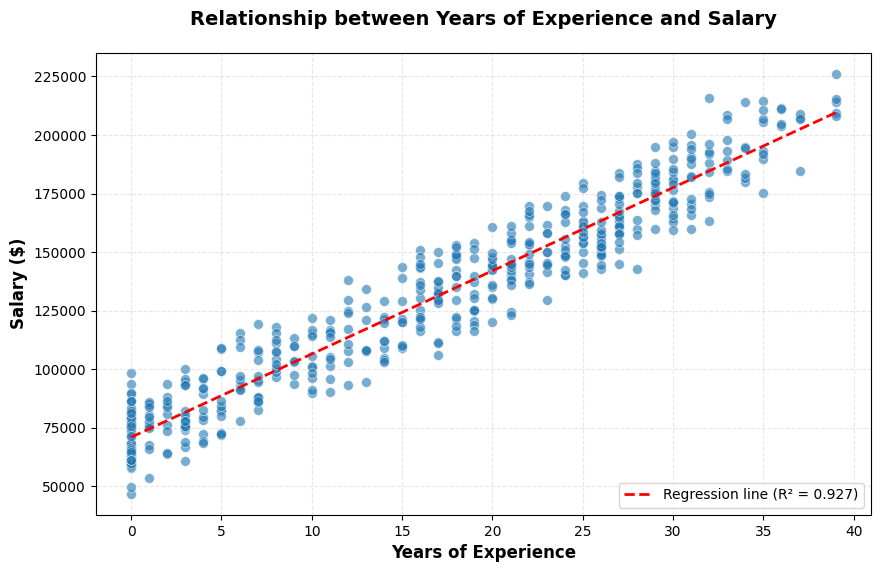

In [40]:
# Create the visualization
fig, ax = plt.subplots(figsize=(10,6))

# Scatter plot
ax.scatter(df['years_experience'], df['salary'], alpha=0.6, s=50, edgecolors='w', linewidth=0.5)

# Add regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(df['years_experience'], df['salary'])
line_x = np.array([df['years_experience'].min(), df['years_experience'].max()])
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, 'r--', linewidth=2, label=f'Regression line (R² = {r_value**2:.3f})')

# Formatting
ax.set_xlabel('Years of Experience', fontsize=12, fontweight="bold")
ax.set_ylabel('Salary ($)', fontsize=12, fontweight="bold")
ax.set_title('Relationship between Years of Experience and Salary', fontsize=14, fontweight="bold", pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=10)
plt.show()

### From the plot:

1. Experience vs Salary:
   - The scatter plot shows a clear upward trend between years of experience and salary.
   - As experience increases, the salary generally increases as well.

2. Regression Line:
   - The red dashed regression line represents the best linear relationship between experience and salary.
   - Most data points lie close to this line, indicating a strong positive correlation.

### Insight:

The graph indicates that **years of experience is a strong predictor of salary**. The high R² value (0.927) suggests that a large portion of salary variation can be explained by the employee’s experience, making it an important feature for the prediction model.

# **Split the Dataset**

In [41]:
# Features (X) and target variable (y)
X = df.drop('salary', axis=1)
y = df['salary']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,  # 80% training data
    test_size=0.2,   # 20% test data
    random_state=42, # ensures reproducibility
    shuffle=True     # shuffles data before splitting
)

# Display sizes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (400, 5)
Testing set size: (100, 5)


# **Data Preprocessing**

# 1. Scale numerical features

In [42]:
 # Numerical features to be scaled
numeric_cols = ["age", "years_experience", "performance_score"]

# Compute mean and standard deviation from training data
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

# Create copies of training & testing data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale numeric features in training & testing data
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.describe()

,age,years_experience,performance_score
count,4.000000e+02,4.000000e+02,4.000000e+02
mean,2.042810e-16,-1.465494e-16,-2.131628e-16
std,1.001252e+00,1.001252e+00,1.001252e+00
min,-1.752130e+00,-1.496408e+00,-1.643422e+00
25%,-7.885788e-01,-8.727189e-01,-9.048674e-01
50%,1.311743e-01,1.073636e-01,2.949960e-02
75%,9.633319e-01,8.201508e-01,8.510615e-01
max,1.576501e+00,1.978430e+00,1.736475e+00


# 2. Encode categorical features

In [43]:
# Categorical features to encode
categorical_cols = ["city", "department"]

X_train_encoded = pd.get_dummies(
    X_train_scaled,
    columns=categorical_cols,               # Convert categorical columns into dummy variables
    drop_first=False                        # Keep all categories (no column dropped)
)
X_train_encoded.head().T                   # Display first rows (transposed for easier viewing)

,249,433,19,322,332
age,-0.263006,-0.788579,-1.664534,-0.700983,-0.525792
years_experience,-0.159932,-1.140014,-1.496408,-0.78362,-0.872719
performance_score,-0.238679,-1.549772,-1.055984,1.234173,1.055388
city_Bangalore,False,False,False,False,False
city_Chennai,True,True,False,False,False
city_Delhi,False,False,False,False,False
city_Hyderabad,False,False,False,True,False
city_Mumbai,False,False,True,False,False
city_Pune,False,False,False,False,True
department_Engineering,False,False,True,True,False


In [44]:
# Categorical features to encode
categorical_cols = ["city", "department"]

X_test_encoded = pd.get_dummies(
    X_test_scaled,
    columns=categorical_cols,               # Convert categorical columns into dummy variables
    drop_first=False                        # Keep all categories (no column dropped)
)
X_test_encoded.head().T                   # Display first rows (transposed for easier viewing)

,361,73,374,155,104
age,0.437759,-0.525792,1.576501,-1.051365,-1.75213
years_experience,0.731052,-0.516325,1.97843,-1.229112,-1.496408
performance_score,0.178488,-0.851657,-0.638818,-0.042866,0.936197
city_Bangalore,False,False,False,True,False
city_Chennai,False,False,False,False,False
city_Delhi,False,False,False,False,False
city_Hyderabad,False,False,False,False,False
city_Mumbai,False,True,True,False,False
city_Pune,True,False,False,False,True
department_Engineering,False,False,False,False,False


# 3. Align Training & Test Data

In [45]:
# Align test set columns with training set columns
X_test_encoded = X_test_encoded[X_train_encoded.columns]
X_test_encoded.columns

Index(['age', 'years_experience', 'performance_score', 'city_Bangalore',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai',
       'city_Pune', 'department_Engineering', 'department_Finance',
       'department_HR', 'department_Marketing', 'department_Operations',
       'department_Sales'],
      dtype='object')

# **Train the Model**

In [46]:
# Create Linear Regression model
model = LinearRegression()
model.fit(X_train_encoded, y_train)

# Make predictions on the data
y_train_pred = model.predict(X_train_encoded)
y_test_pred = model.predict(X_test_encoded)

# **Evaluating the Model**

In [47]:
# R² score for training & test data
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Root Mean Square(RMSE) score for training & test data
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Mean Absolute Error(MAE) score for training & test data
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

In [48]:
# Results of Evaluation for training data
print("Training data performance")
print("-------------------------")
print(f"R² score : {train_r2:.4f}")
print(f"RMSE score: ${train_rmse:.2f}")
print(f"MAE score: ${train_mae:.2f}")

Training data performance
-------------------------
R² score : 0.9865
RMSE score: $4832.23
MAE score: $3837.12


In [49]:
# Results of Evaluation for test data
print("Test data performance")
print("-------------------------")
print(f"R² score : {test_r2:.4f}")
print(f"RMSE score: ${test_rmse:.2f}")
print(f"MAE score: ${test_mae:.2f}")

Test data performance
-------------------------
R² score : 0.9868
RMSE score: $4606.65
MAE score: $3737.57


# **Data Visualization**

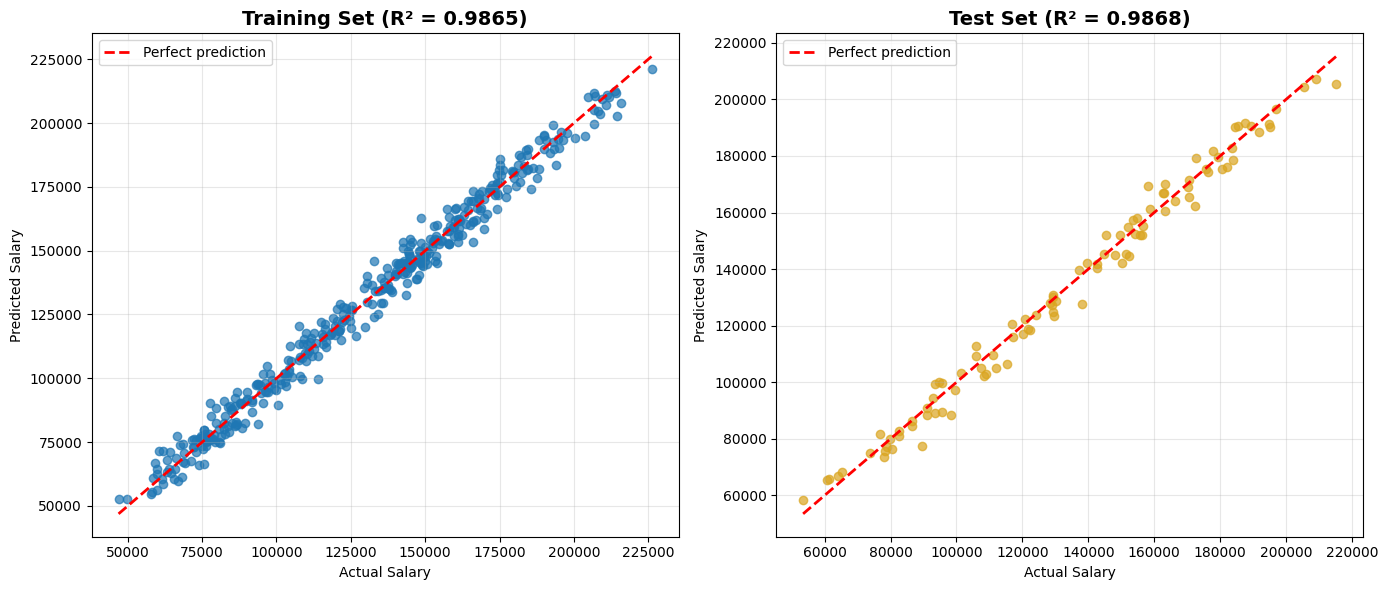

In [50]:
# Create two plots
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# -------- Training Plot --------
ax[0].scatter(y_train, y_train_pred, alpha=0.7)
ax[0].plot([y_train.min(), y_train.max()],
           [y_train.min(), y_train.max()],
           'r--', linewidth=2, label='Perfect prediction')
ax[0].set_title(f"Training Set (R² = {train_r2:.4f})", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Actual Salary")
ax[0].set_ylabel("Predicted Salary")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# -------- Test Plot --------
ax[1].scatter(y_test, y_test_pred, alpha=0.7, color='goldenrod')
ax[1].plot([y_test.min(), y_test.max()],
           [y_test.min(), y_test.max()],
           'r--', linewidth=2, label='Perfect prediction')
ax[1].set_title(f"Test Set (R² = {test_r2:.4f})", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Actual Salary")
ax[1].set_ylabel("Predicted Salary")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### From the plots:

1. Training Set:
   - Most predicted salary values lie very close to the perfect prediction line.
   - This indicates that the model fits the training data extremely well.

2. Test Set:
   - The predicted values in the test set also closely follow the perfect prediction line.
   - Only small deviations are visible, showing that the model performs well on unseen data.

### Insight:

The Linear Regression model shows excellent performance with very high R² values (~0.986) for both training and testing datasets. This indicates that the model explains most of the variance in employee salaries and generalizes well without significant overfitting.

# **Model Delpoyment**

In [53]:
# Save the trained model
joblib.dump(model, "salary_model.pkl")

# Save the scaler used for scaling the features
joblib.dump(scaler, "salary_scaler.pkl")

# Save encoded column names
joblib.dump(X_train_encoded.columns, "salary_columns.pkl")

['salary_columns.pkl']

In [54]:
# Code for Streamlit App
code = '''
import streamlit as st
import pandas as pd
import joblib

# Load saved objects
model = joblib.load("salary_model.pkl")
scaler = joblib.load("salary_scaler.pkl")
columns = joblib.load("salary_columns.pkl")

st.title("Employee Salary Prediction")

age = st.number_input("Age",18,65)
experience = st.number_input("Years of Experience",0,40)
performance = st.slider("Performance Score",1.0,5.0)

city = st.selectbox("City",
["Bangalore","Hyderabad","Pune","Delhi","Mumbai","Chennai"])

department = st.selectbox("Department",
["Engineering","Marketing","Sales","HR","Finance","Operations"])

input_data = pd.DataFrame({
"age":[age],
"years_experience":[experience],
"performance_score":[performance],
"city":[city],
"department":[department]
})

# One-hot encoding
input_data = pd.get_dummies(input_data)

# Match training columns
input_data = input_data.reindex(columns=columns, fill_value=0)

# Prediction
if st.button("Predict Salary"):
    prediction = model.predict(input_data)
    st.success(f"Predicted Salary: ${prediction[0]:,.2f}")
'''
with open("salary_prediction_system_app.py", "w") as f:
  f.write(code)

In [56]:
files.download("salary_prediction_system_app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>